`desi_hsc_footprintmatch.ipynb`

This notebook intends to recover any catalog and sample it on the HSC MOC.
It also provides insights on how to build and plot the HSC MOC for its footprint.

In [1]:
## Imports
import time
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from mocpy import WCS as MOCWCS
from mocpy import MOC
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.io import fits
from astropy.table import Table, vstack

In [ ]:
USER_ROOT = Path('/global/cfs/cdirs/desicollab/users/jchdj')
DATA_ROOT = USER_ROOT / 'desi-y3-hsc' / 'data'
DESI_ROOT = DATA_ROOT / 'desi' / 'tests'
HSC_ROOT = DATA_ROOT / 'hsc' / 'cat'
XMATCH_ROOT = DATA_ROOT / 'xmatch'
DESI_ROOT = '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP'
DESI_WEIGHTS_ROOT = DATA_ROOT / 'desi' / 'weights'

MOC_ROOT = DATA_ROOT / 'mocs'

desi_file = Path(DESI_ROOT, 'desiy3_cut_cat.fits')
desi_tgts = [Path(DESI_ROOT, f'{tgt}_{cap}_{i}_clustering.ran.fits') for tgt in ['BGS_ANY', 'ELG_LOPnotqso', 'LRG', 'QSO'] for cap in ['NGC', 'SGC'] for i in range(1, 3)]
print(f'DESI sampled catalog : {desi_file}')
hsc_file = Path(HSC_ROOT, 'hscy3_cat.fits')
print(f'HSC catalog : {hsc_file}')

DESI sampled catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/desiy3_cut_cat.fits
HSC catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits


In [12]:
tbls = []
for desi_tgt in desi_tgts:
    print(f'DESI target catalog : {desi_tgt}')
    dt = Table(fio.read(desi_tgt, columns=['RA', 'DEC', 'Z']))
    tbls.append(dt)
# We stack 2 random catalogs of each tracer of DESI to get an 
# accurate representation of the DESI footprint. More can cause kernel crashes.
desi = vstack(tbls)

DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/BGS_ANY_NGC_1_clustering.ran.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/BGS_ANY_NGC_2_clustering.ran.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/ELG_LOPnotqso_NGC_1_clustering.ran.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/ELG_LOPnotqso_NGC_2_clustering.ran.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/LRG_NGC_1_clustering.ran.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/LRG_NGC_2_clustering.ran.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/QSO_NGC_1_clustering.ran.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP/QSO_NGC_2_clustering.ran.f

In [13]:
# Read the HSC catalog (ETA ~ 8s)
hsc = Table(fio.read(hsc_file, columns=['ra', 'dec', 'dnnz_photoz_best']))

In [14]:
# Load HSC galaxy coordinates
hsc_coords = SkyCoord(ra=hsc['ra']*u.deg, dec=hsc['dec']*u.deg)
# DESI galaxy coordinates
desi_coords = SkyCoord(ra=desi['RA']*u.deg, dec=desi['DEC']*u.deg)
# Available column names
print(hsc.dtype.names)
print(desi.dtype.names)

('ra', 'dec', 'dnnz_photoz_best')
('RA', 'DEC', 'Z')


In [6]:
desi_master_moc = MOC.from_skycoords(desi_coords, max_norder=10) 

In [8]:
desi_master_moc.max_order

10

/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits


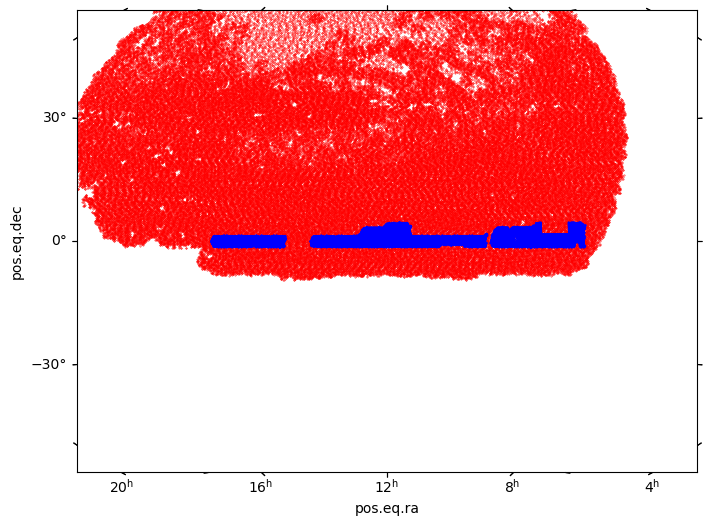

In [28]:
moc_list = [f'{MOC_ROOT}/hsc_moc{i}.fits' for i in range(1, 5)]
print(moc_list[0])
hsc_moc = MOC.from_fits(moc_list[0])

fig = plt.figure(figsize=(8, 6))
with MOCWCS(fig,
    fov=120 * u.deg,
    center=SkyCoord(180, 0, unit='deg', frame='icrs'),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)
#desi_master_moc.border(ax=ax, wcs=wcs, alpha=0.7, color="red")
#intersected_moc.border(ax=ax, wcs=wcs, alpha=0.7, color="green")
ax.scatter(desi_coords.ra.deg[0::1000], desi_coords.dec.deg[0::1000], s=0.1, color='red',transform=ax.get_transform('world'))
hsc_moc.border(ax=ax, wcs=wcs, alpha=0.7, color="blue")
hsc_moc.fill(ax=ax, wcs=wcs, alpha=1, color="blue")

In [ ]:
moc_list = [f'{MOC_ROOT}/hsc_moc{i}.fits' for i in range(1, 5)]
hsc_mocs = [MOC.from_fits(moc_file) for moc_file in moc_list]
hsc_mocs[0].norder

In [16]:
# Calculate total survey area from MOC files
def skyfraction_to_area(sky_fraction):
    """Convert sky fraction to area in steradians."""
    return sky_fraction * 4 * np.pi * (180/np.pi)**2 # Convert from sky fraction to steradians and then to square degrees

Processing HSC MOC 1
['MAX_ORDER', '__abstractmethods__', '__add__', '__and__', '__class__', '__copy__', '__deepcopy__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__invert__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__radd__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_abc_impl', '_fits_format', '_fits_header_keywords', '_from_fits_raw_bytes', '_query', '_store_index_dtype', 'add_neighbours', 'barycenter', 'border', 'complement', 'contains', 'contains_lonlat', 'contains_skycoords', 'contracted', 'degrade_to_order', 'difference', 'display_preview', 'empty', 'extended', 'fill', 'flatten', 'from_astropy_regions', 'from_box', 'from_boxes', 'from_cone', 'from_cones', 'from_depth29_ranges', 'from_elliptical_cone', 'from_fi

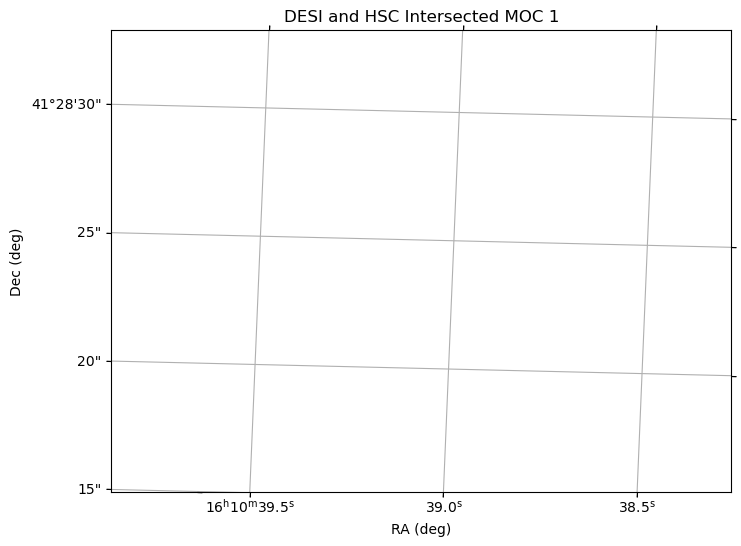

Processing HSC MOC 2
['MAX_ORDER', '__abstractmethods__', '__add__', '__and__', '__class__', '__copy__', '__deepcopy__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__invert__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__radd__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_abc_impl', '_fits_format', '_fits_header_keywords', '_from_fits_raw_bytes', '_query', '_store_index_dtype', 'add_neighbours', 'barycenter', 'border', 'complement', 'contains', 'contains_lonlat', 'contains_skycoords', 'contracted', 'degrade_to_order', 'difference', 'display_preview', 'empty', 'extended', 'fill', 'flatten', 'from_astropy_regions', 'from_box', 'from_boxes', 'from_cone', 'from_cones', 'from_depth29_ranges', 'from_elliptical_cone', 'from_fi

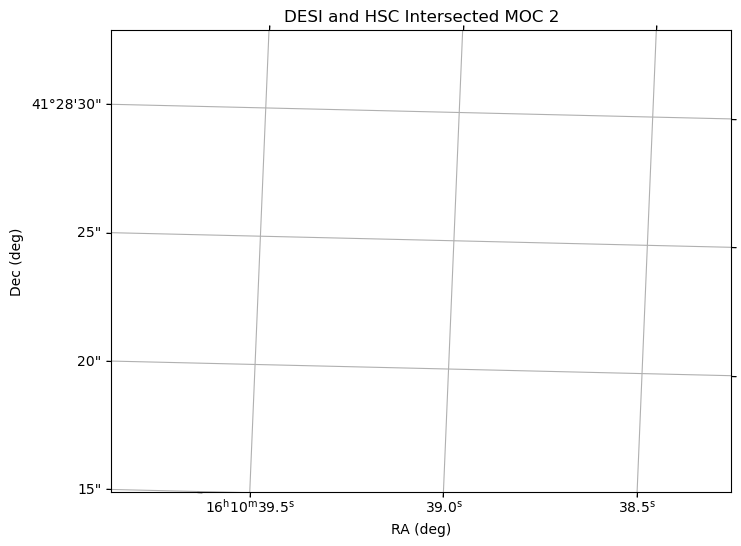

Processing HSC MOC 3
['MAX_ORDER', '__abstractmethods__', '__add__', '__and__', '__class__', '__copy__', '__deepcopy__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__invert__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__radd__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_abc_impl', '_fits_format', '_fits_header_keywords', '_from_fits_raw_bytes', '_query', '_store_index_dtype', 'add_neighbours', 'barycenter', 'border', 'complement', 'contains', 'contains_lonlat', 'contains_skycoords', 'contracted', 'degrade_to_order', 'difference', 'display_preview', 'empty', 'extended', 'fill', 'flatten', 'from_astropy_regions', 'from_box', 'from_boxes', 'from_cone', 'from_cones', 'from_depth29_ranges', 'from_elliptical_cone', 'from_fi

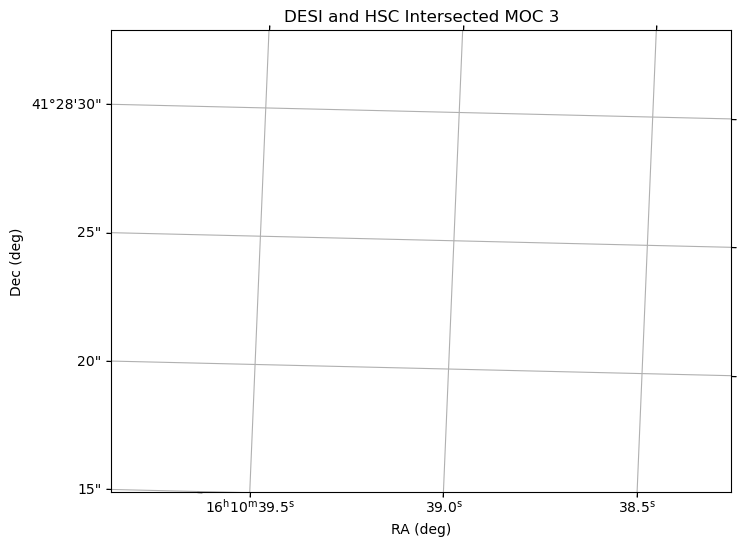

Processing HSC MOC 4
['MAX_ORDER', '__abstractmethods__', '__add__', '__and__', '__class__', '__copy__', '__deepcopy__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__invert__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__radd__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_abc_impl', '_fits_format', '_fits_header_keywords', '_from_fits_raw_bytes', '_query', '_store_index_dtype', 'add_neighbours', 'barycenter', 'border', 'complement', 'contains', 'contains_lonlat', 'contains_skycoords', 'contracted', 'degrade_to_order', 'difference', 'display_preview', 'empty', 'extended', 'fill', 'flatten', 'from_astropy_regions', 'from_box', 'from_boxes', 'from_cone', 'from_cones', 'from_depth29_ranges', 'from_elliptical_cone', 'from_fi

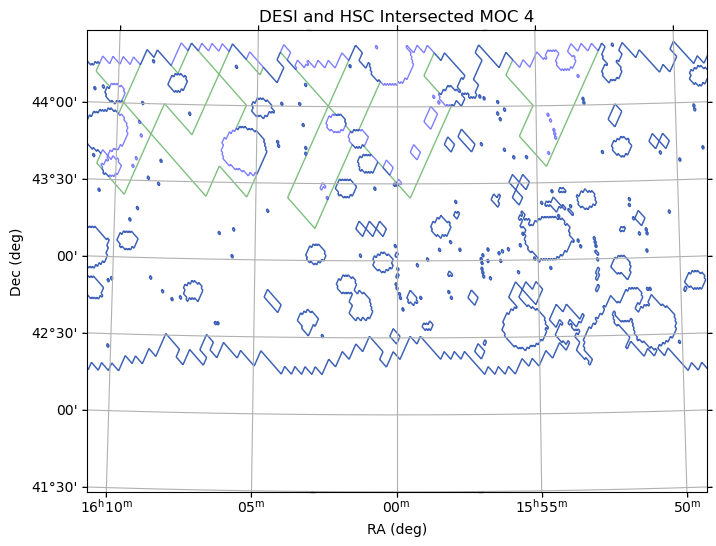

In [ ]:
for i, hsc_moc in enumerate(hsc_mocs):
    print(f'Processing HSC MOC {i+1}')
    # Intersect DESI master MOC with HSC MOC
    intersected_moc = desi_master_moc.intersection(hsc_moc)

    # Save the intersected MOC to a FITS file
    Path(f'{MOC_ROOT}_intersect').mkdir(parents=True, exist_ok=True)
    print(dir(intersected_moc))
    moc_filename = f'{MOC_ROOT}_intersect/hsc_moc{i+1}.fits'
    intersected_moc.save(moc_filename, overwrite=True)
    print(f'Saved intersected MOC to {moc_filename}')
    print(f"Sky fraction of the intersected MOC: {skyfraction_to_area(intersected_moc.sky_fraction):.7f} deg^2")
    print(f"Sky fraction pre-intersection (DESI): {skyfraction_to_area(desi_master_moc.sky_fraction):.7f} deg^2")
    print(f"Sky fraction of HSC MOC {i+1}: {skyfraction_to_area(hsc_moc.sky_fraction):.7f} deg^2")
    # Optionally, visualize the MOC
    fig = plt.figure(figsize=(8, 6))
    with MOCWCS(fig,
           fov=3 * u.deg,
           center=SkyCoord(240, 43, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
    ax = fig.add_subplot(projection=wcs)
    intersected_moc.border(ax=ax, wcs=wcs, alpha=0.5, color="green")
    hsc_moc.border(ax=ax, wcs=wcs, alpha=0.5, color="blue")
    #intersected_moc.border(ax=ax, wcs=wcs, alpha=0.5, color="black")
    plt.title(f'DESI and HSC Intersected MOC {i+1}')
    plt.xlabel('RA (deg)')
    plt.ylabel('Dec (deg)')
    plt.grid()
    plt.show()

Text(0, 0.5, 'DEC (deg)')

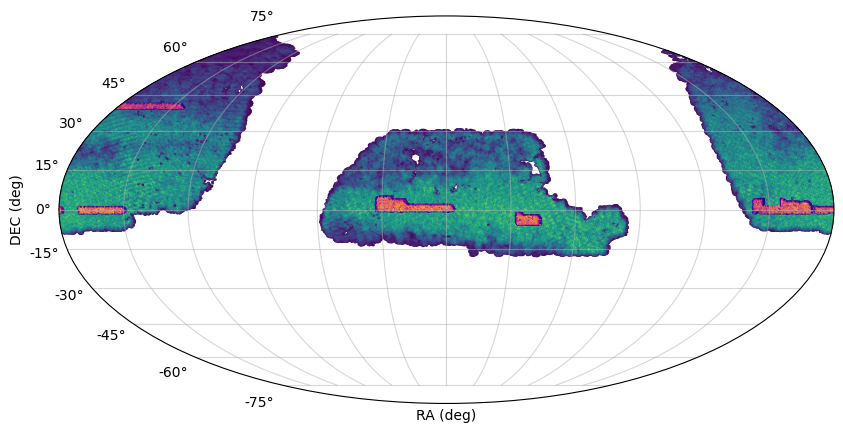

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'mollweide'})

hsc_ra = hsc_coords.ra.wrap_at(180 * u.deg).radian
hsc_dec = hsc_coords.dec.radian
desi_ra = desi_coords.ra.wrap_at(180 * u.deg).radian
desi_dec = desi_coords.dec.radian

# Store the return values of hexbin (collections)
hb_desi = ax.hexbin(desi_ra, desi_dec, mincnt=1, gridsize=750, bins=50, cmap='viridis', alpha=0.7)
hb_hsc = ax.hexbin(hsc_ra, hsc_dec, mincnt=1, gridsize=750, bins=50, cmap='plasma', alpha=0.7)

# Add colorbars
#cb1 = fig.colorbar(hb_desi, ax=ax, orientation='horizontal', fraction=0.03, pad=0.07)
#cb1.set_label('DESI Density')

#cb2 = fig.colorbar(hb_hsc, ax=ax, orientation='horizontal', fraction=0.03, pad=0.12)
#cb2.set_label('HSC Density')

ax.grid(alpha=0.5)
ax.set_xticklabels([])
ax.set_xlabel('RA (deg)')
ax.set_ylabel('DEC (deg)')


In [33]:
bounds = [[120, 240], [-15, 15]] # first patch
bounds = [[20, 60], [-15, 15]] # second patch
bounds = [[310, 20], [-15, 15]] # third patch
bounds = [[0, 360], [30, 80]] # fourth patch

In [34]:
def spatial_crit(coords, bounds):
    '''Returns a mask based on boundaries.'''
    ra = coords.ra.deg
    dec = coords.dec.deg

    if bounds[0][0] > bounds[0][1]:
        mask_ra = (ra > bounds[0][0]) | (ra < bounds[0][1])
    else:
        mask_ra = (ra > bounds[0][0]) & (ra < bounds[0][1])
    if bounds[1][0] > bounds[1][1]:
        mask_dec = (dec > bounds[1][0]) | (dec < bounds[1][1])
    else:   
        mask_dec = (dec > bounds[1][0]) & (dec < bounds[1][1])
    mask = mask_ra & mask_dec

    return mask

In [35]:
hsc_sample = hsc_coords[spatial_crit(hsc_coords, bounds)]

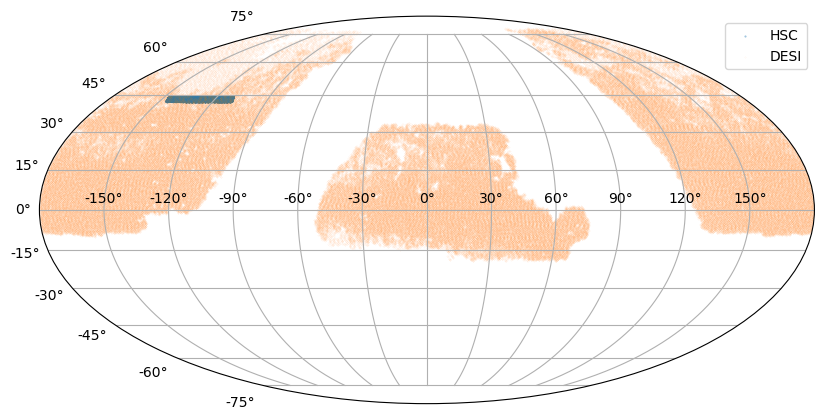

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'mollweide'})
hsc_ra = hsc_sample.ra.wrap_at(180 * u.deg).radian
hsc_dec = hsc_sample.dec.radian
desi_ra = desi_coords.ra.wrap_at(180 * u.deg).radian
desi_dec = desi_coords.dec.radian

ax.scatter(hsc_ra[0::100], hsc_dec[0::100], s=0.2, alpha=0.5, label='HSC')
ax.scatter(desi_ra[0::1000], desi_dec[0::1000], s=0.04, alpha=0.1, label='DESI')
ax.legend()
ax.grid()
plt.show()

In [37]:
# Generate a MOC from HSC positions to cover HSC's footprint. Compute spatial resolution in arcsec.
n_order = 13
print(f'Spatial resolution of MOC (order : {n_order}): {MOC.order_to_spatial_resolution(n_order).to(u.arcsec):.3f}')
hsc_moc = MOC.from_skycoords(hsc_sample, max_norder=n_order)
Path(f'{MOC_ROOT}_{n_order}').mkdir(parents=True, exist_ok=True)
hsc_moc.save(f'{MOC_ROOT}_{n_order}/hsc_moc4_order13.fits', format='fits', overwrite=True)

Spatial resolution of MOC (order : 13): 25.766 arcsec


In [40]:
order1 = 12
tot1 = 0.0
order2 = 13
tot2 = 0.0
for i in range(1, 5):
    moc_area1 = skyfraction_to_area(MOC.from_fits(f'{MOC_ROOT}_{order1}/hsc_moc{i}.fits').sky_fraction)
    moc_area2 = skyfraction_to_area(MOC.from_fits(f'{MOC_ROOT}_{order2}/hsc_moc{i}_order{order2}.fits').sky_fraction)
    print(f'HSC MOC {i} area order1 : {moc_area1:.7f} deg^2')
    print(f'HSC MOC {i} area order2 : {moc_area2:.7f} deg^2')
    tot1 += moc_area1
    tot2 += moc_area2
print(f'Total area order1 : {tot1:.7f} deg^2')
print(f'Total area order2 : {tot2:.7f} deg^2')

HSC MOC 1 area order1 : 267.5471841 deg^2
HSC MOC 1 area order2 : 248.3093075 deg^2
HSC MOC 2 area order1 : 35.6294086 deg^2
HSC MOC 2 area order2 : 32.9208117 deg^2
HSC MOC 3 area order1 : 105.6116634 deg^2
HSC MOC 3 area order2 : 97.8021959 deg^2
HSC MOC 4 area order1 : 46.6666528 deg^2
HSC MOC 4 area order2 : 43.4387737 deg^2
Total area order1 : 455.4549090 deg^2
Total area order2 : 422.4710888 deg^2


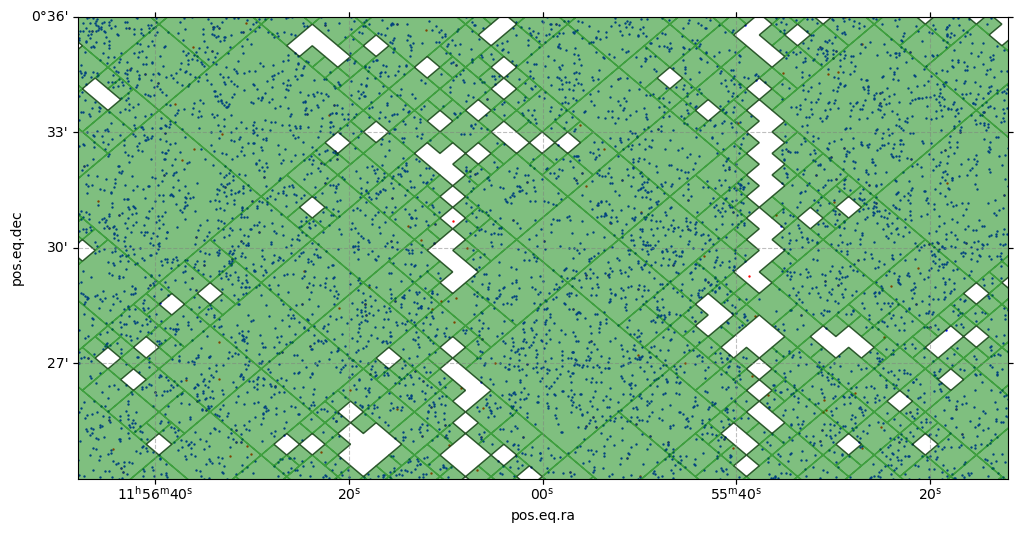

In [26]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=0.2 * u.deg,
           center=SkyCoord(179, 0.5, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)
ax.scatter(
    desi_coords.ra.deg, 
    desi_coords.dec.deg,
    transform=ax.get_transform('world'),
    s=0.5, 
    color='red', 
    label='DESI targets'
    )
ax.scatter(
    hsc_coords.ra.deg,
    hsc_coords.dec.deg,
    transform=ax.get_transform('world'),
    s=0.5,
    color='blue',
    label='HSC targets'
    )
hsc_moc.fill(ax=ax, wcs=wcs, alpha=0.5, fill=True, color="green")
hsc_moc.border(ax=ax, wcs=wcs, alpha=0.5, color="black")
ax.grid(color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('DEC (deg)')
ax.legend()

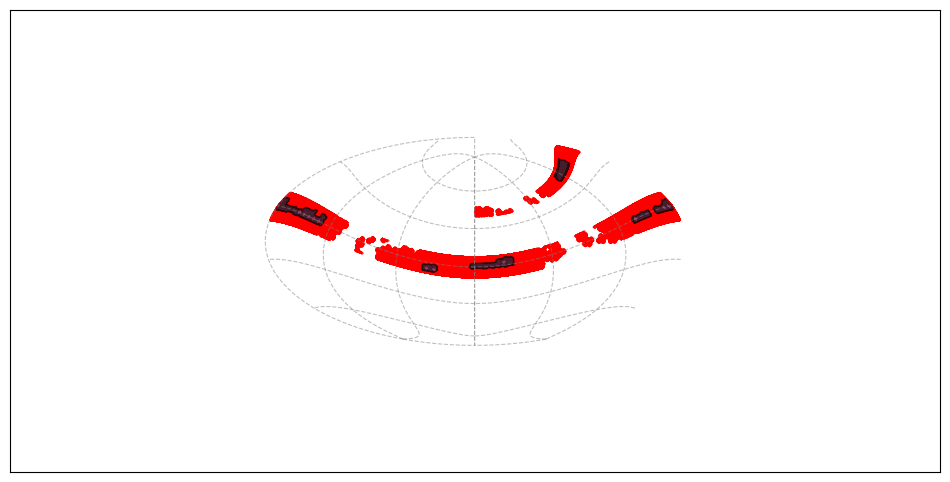

In [73]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=360 * u.deg,
           center=SkyCoord(0, 20, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)
ax.scatter(
    desi_coords.ra.deg[0::10], 
    desi_coords.dec.deg[0::10],
    transform=ax.get_transform('world'),
    s=0.005, 
    color='red', 
    label='DESI targets'
    )
moc_list = glob.glob(f'{MOC_ROOT}/hsc_moc*.fits')
for mocf in moc_list:
    moc = MOC.from_fits(mocf)
    moc.fill(ax=ax, wcs=wcs, alpha=0.5, fill=True)
    moc.border(ax=ax, wcs=wcs, alpha=0.5, color="black")
ax.grid(color='gray', linestyle='--', alpha=0.5)

In [27]:
hsc_moc.save(
    os.path.join(XMATCH_ROOT, 'hsc_moc.fits'),
    overwrite=True,
)

In [ ]:
mask = hsc_moc.contains_skycoords(desi_coords, keep_inside=True)
print(f'DESI catalog size : {len(desi)}')
desi_masked = desi[np.flatnonzero(mask)]
print(f'DESI catalog size on HSC MOC : {len(desi_masked)}')
desi_masked_coords = SkyCoord(ra=desi_masked['TARGET_RA']*u.deg, dec=desi_masked['TARGET_DEC']*u.deg)

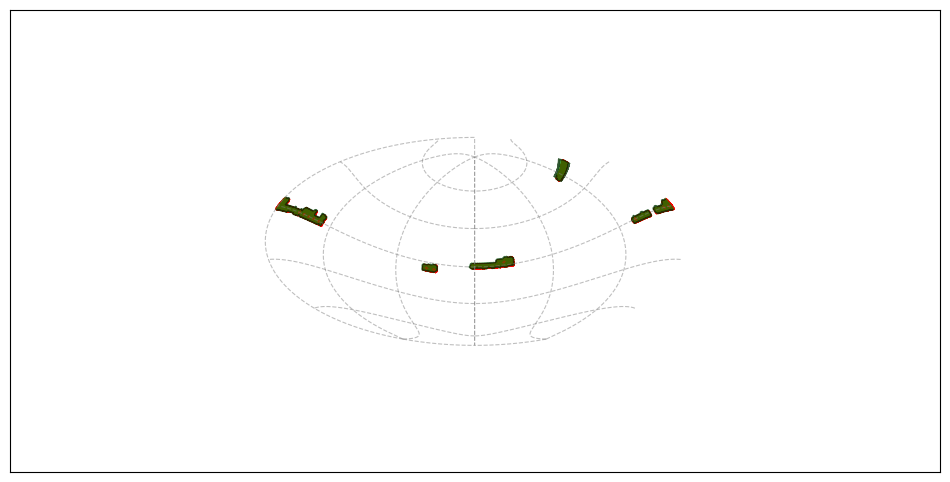

In [30]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=360 * u.deg,
           center=SkyCoord(0, 20, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)
ax.scatter(
    desi_masked_coords.ra.deg[0::10], 
    desi_masked_coords.dec.deg[0::10],
    transform=ax.get_transform('world'),
    s=0.005, 
    color='red', 
    label='DESI targets'
    )
hsc_moc.fill(ax=ax, wcs=wcs, alpha=0.5, fill=True, color="green")
hsc_moc.border(ax=ax, wcs=wcs, alpha=0.5, color="black")
ax.grid(color='gray', linestyle='--', alpha=0.5)

In [31]:
fio.write(XMATCH_ROOT / 'desi_hsc.fits', desi_masked, clobber=True)

DESI catalog size : 22971426
Spatial resolution of MOC : 3298.067 arcsec
DESI footprint catalog size : 5275768
Spatial resolution of MOC : 1649.033 arcsec
DESI footprint catalog size : 4551404
Spatial resolution of MOC : 824.517 arcsec
DESI footprint catalog size : 4200102
Spatial resolution of MOC : 412.258 arcsec
DESI footprint catalog size : 3922568
Spatial resolution of MOC : 206.129 arcsec
DESI footprint catalog size : 3599932
Spatial resolution of MOC : 103.065 arcsec
DESI footprint catalog size : 3510583
Spatial resolution of MOC : 51.532 arcsec
DESI footprint catalog size : 3434227
Spatial resolution of MOC : 25.766 arcsec
DESI footprint catalog size : 3061959
Spatial resolution of MOC : 12.883 arcsec
DESI footprint catalog size : 1878727
Spatial resolution of MOC : 6.442 arcsec
DESI footprint catalog size : 1135984
Spatial resolution of MOC : 3.221 arcsec
DESI footprint catalog size : 909326
Spatial resolution of MOC : 1.610 arcsec
DESI footprint catalog size : 839792


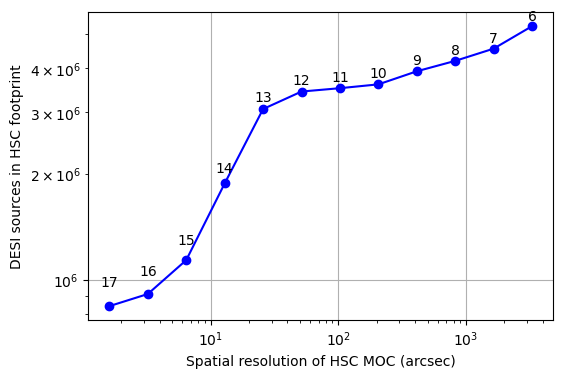

In [ ]:
# ETA ~ 2min10
orders = np.arange(6, 18)
res = []
size = []
print(f'DESI catalog size : {len(desi)}')
for i in orders:
    res.append(MOC.order_to_spatial_resolution(i).to(u.arcsec))
    hsc_moc = MOC.from_skycoords(hsc_coords, max_norder=i)
    mask = hsc_moc.contains_skycoords(desi_coords, keep_inside=True)
    size.append(len(np.flatnonzero(mask)))
    print(f'Spatial resolution of MOC : {res[-1]:.3f}, DESI footprint catalog size : {size[-1]}')

plt.figure(figsize=(6, 4))
resolution = [r.value for r in res]
plt.plot(resolution, size, marker='o', color='blue')
for i in range(len(resolution)):
    plt.text(resolution[i], size[i]+1e5, str(orders[i]), ha='center', va='bottom')
plt.xlabel('Spatial resolution of HSC MOC (arcsec)')
plt.ylabel('DESI sources in HSC footprint')
plt.xscale('log')
plt.yscale('log')
plt.grid()

In [ ]:
## Extract the weights and append them to the original catalog
for target in ['LRG', 'ELG', 'QSO', 'BGS']:
    print(glob.glob(f'{DESI_ROOT}/*{target}*_full.dat.fits'))

['/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/LRG_full.dat.fits']
['/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/ELG_LOPnotqso_full.dat.fits', '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/ELGnotqso_full.dat.fits']
['/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_full.dat.fits']
['/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/BGS_BRIGHT_full.dat.fits', '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/BGS_ANY_full.dat.fits']


In [35]:
lrg = fio.FITS('/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/LRG_full.dat.fits')
lrg[1].get_colnames()

['TARGETID',
 'MWS_TARGET',
 'SUBPRIORITY',
 'PRIORITY_INIT',
 'TARGET_STATE',
 'TIMESTAMP',
 'PRIORITY',
 'LOCATION',
 'TILEID',
 'TILELOCID',
 'LASTNIGHT',
 'Z_not4clus',
 'ZERR',
 'ZWARN',
 'CHI2',
 'COEFF',
 'NPIXELS',
 'SPECTYPE',
 'SUBTYPE',
 'NCOEFF',
 'DELTACHI2',
 'FIBER',
 'COADD_FIBERSTATUS',
 'FIBERASSIGN_X',
 'FIBERASSIGN_Y',
 'COADD_NUMEXP',
 'COADD_EXPTIME',
 'COADD_NUMNIGHT',
 'MEAN_DELTA_X',
 'RMS_DELTA_X',
 'MEAN_DELTA_Y',
 'RMS_DELTA_Y',
 'MEAN_PSF_TO_FIBER_SPECFLUX',
 'TSNR2_BGS_B',
 'TSNR2_ELG_B',
 'TSNR2_LRG_B',
 'TSNR2_LYA_B',
 'TSNR2_QSO_B',
 'TSNR2_BGS_R',
 'TSNR2_ELG_R',
 'TSNR2_LRG_R',
 'TSNR2_LYA_R',
 'TSNR2_QSO_R',
 'TSNR2_BGS_Z',
 'TSNR2_ELG_Z',
 'TSNR2_LRG_Z',
 'TSNR2_LYA_Z',
 'TSNR2_QSO_Z',
 'TSNR2_BGS',
 'TSNR2_ELG',
 'TSNR2_LRG',
 'TSNR2_LYA',
 'TSNR2_QSO',
 'ZWARN_MTL',
 'Z_QN',
 'Z_QN_CONF',
 'IS_QSO_QN',
 'PRIORITY_ASSIGNED',
 'GOODPRI',
 'GOODHARDLOC',
 'LOCATION_ASSIGNED',
 'TILELOCID_ASSIGNED',
 'NTILE',
 'TILES',
 'BRICKID',
 'BRICKNAME',
 'MORP

Selecting the weights on HSC's footprint for LRG, BGS, ELG and QSOs

In [36]:
tbl=fio.FITS('/global/cfs/cdirs/desicollab/science/c3/DESI-Lensing/desi_catalogues/weight_prob_obs/hscy3/LRG_clustering.dat.fits')
tbl[1].get_colnames()

['TARGETID',
 'Z',
 'NTILE',
 'RA',
 'DEC',
 'PHOTSYS',
 'FRAC_TLOBS_TILES',
 'WEIGHT_ZFAIL',
 'BITWEIGHTS',
 'PROB_OBS',
 'WEIGHT_SYS',
 'WEIGHT',
 'WEIGHT_COMP']

In [38]:
# Precompute the MOC
hsc = fio.read(hsc_file)
hsc_coords = SkyCoord(
    ra=hsc['RA']*u.deg, 
    dec=hsc['Dec']*u.deg
    )
hsc_moc = MOC.from_skycoords(hsc_coords, max_norder=12)

In [ ]:
def sample_weight_selection(hsc_moc, in_file, out_file, randoms=False, logtxt=None):
    '''
    Function to select the weights from the entire sky and 
    sample them on HSC's footprint.
    '''
    
    t0 = time.time()
    in_file = Path(DESI_ROOT, in_file)
    out_file = Path(DESI_WEIGHTS_ROOT, out_file if not randoms else f'../randoms/{out_file}')

    desi = fio.FITS(in_file)
    coords = SkyCoord(
        ra=desi[1]['RA'].read()*u.deg, 
        dec=desi[1]['DEC'].read()*u.deg
        )
    mask = hsc_moc.contains_skycoords(coords, keep_inside=True)
    desi_masked = desi[1].read(rows=np.flatnonzero(mask))
    fio.write(out_file, desi_masked, clobber=True)
    if logtxt is not None:
        with open(logtxt, 'a') as f:
            f.write(f'DESI catalog size : {desi[1].get_nrows()}\n')
            f.write(f'DESI catalog size on HSC MOC : {len(desi_masked)}\n')
            f.write(f'Finished writing {out_file} ... time taken : {time.time()-t0:.2f}s\n')

In [ ]:
f'{DESI_ROOT}/QSO_full.dat.fits'

'/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1//QSO_full.dat.fits'

In [ ]:
[str(Path(f).stem) for f in glob.glob(f'{DESI_ROOT}/*')]

['QSO_S_2.13.5_linimsysfit',
 'sysnet',
 'BGS_BRIGHT-21.5_N_0.10.4_linimsysfit',
 'QSO_6_full_HPmapcut.ran',
 'BGS_ANY_13_full.ran',
 'dark_9_full_noveto.ran',
 'ELG_LOPnotqso_8_full.ran',
 'BGS_ANYNmaxssrvsflux',
 'dark_12_full_noveto.ran',
 'BGS_ANY_1_full.ran',
 'ELG_LOPnotqso_10_full_HPmapcut.ran',
 'QSO_N_2.13.5_linimsysfit',
 'LRG_full_HPmapcut.dat',
 'dark_6_full_noveto.ran',
 'BGS_ANY_3_full_HPmapcut.ran',
 'BGS_ANYNpars_overall',
 'BGS_BRIGHT_11_full.ran',
 'bright_15_full_noveto.ran',
 'LRGSoverall_failratefit',
 'LRG_S_0.81.1_linimsysfit',
 'QSO_17_full.ran',
 'BGS_ANY_8_full.ran',
 'QSO_full_HPmapcut.dat',
 'ELG_LOPnotqso_12_full.ran',
 'BGS_BRIGHT_13_full.ran',
 'BGS_ANY_11_full_HPmapcut.ran',
 'LRG_9_full_HPmapcut.ran',
 'ELG_LOPnotqso_1_full.ran',
 'ELG_LOPnotqso_12_full_HPmapcut.ran',
 'BGS_BRIGHT_3_full.ran',
 'QSO_2_full.ran',
 'BGS_ANYSpars_overall',
 'QSO_14_full_HPmapcut.ran',
 'ELG_LOPnotqso_11_full_HPmapcut.ran',
 'ELG_LOPnotqso_frac_tlobs',
 'regressis_data',
 '

In [ ]:
import fitsio as fio
pt = f'{DESI_ROOT}/QSO_full.dat.fits'
qso = fio.FITS(pt)
print(pt)
qso[1].get_colnames()

/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1//QSO_full.dat.fits


['TARGETID',
 'MWS_TARGET',
 'SUBPRIORITY',
 'PRIORITY_INIT',
 'TARGET_STATE',
 'TIMESTAMP',
 'PRIORITY',
 'LOCATION',
 'TILEID',
 'TILELOCID',
 'LASTNIGHT',
 'Z_RR',
 'ZERR',
 'ZWARN',
 'CHI2',
 'COEFF',
 'NPIXELS',
 'SPECTYPE',
 'SUBTYPE',
 'NCOEFF',
 'DELTACHI2',
 'FIBER',
 'COADD_FIBERSTATUS',
 'FIBERASSIGN_X',
 'FIBERASSIGN_Y',
 'COADD_NUMEXP',
 'COADD_EXPTIME',
 'COADD_NUMNIGHT',
 'MEAN_DELTA_X',
 'RMS_DELTA_X',
 'MEAN_DELTA_Y',
 'RMS_DELTA_Y',
 'MEAN_PSF_TO_FIBER_SPECFLUX',
 'TSNR2_BGS_B',
 'TSNR2_ELG_B',
 'TSNR2_LRG_B',
 'TSNR2_LYA_B',
 'TSNR2_QSO_B',
 'TSNR2_BGS_R',
 'TSNR2_ELG_R',
 'TSNR2_LRG_R',
 'TSNR2_LYA_R',
 'TSNR2_QSO_R',
 'TSNR2_BGS_Z',
 'TSNR2_ELG_Z',
 'TSNR2_LRG_Z',
 'TSNR2_LYA_Z',
 'TSNR2_QSO_Z',
 'TSNR2_BGS',
 'TSNR2_ELG',
 'TSNR2_LRG',
 'TSNR2_LYA',
 'TSNR2_QSO',
 'ZWARN_MTL',
 'Z_QN',
 'Z_QN_CONF',
 'IS_QSO_QN',
 'PRIORITY_ASSIGNED',
 'GOODPRI',
 'GOODHARDLOC',
 'LOCATION_ASSIGNED',
 'TILELOCID_ASSIGNED',
 'NTILE',
 'TILES',
 'BRICKID',
 'BRICKNAME',
 'MORPHTYPE'

In [56]:
sample_weight_selection(hsc_moc, 'BGS_ANY_full.dat.fits', 'bgs_hsc_weights.fits')

DESI catalog size : 17858989
DESI catalog size on HSC MOC : 600841
Finished writing /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/weights/bgs_hsc_weights.fits ... time taken : 28.92s


In [51]:
sample_weight_selection(hsc_moc, 'LRG_full.dat.fits', 'lrg_hsc_weights.fits')

DESI catalog size : 6251937
DESI catalog size on HSC MOC : 248725
Finished writing /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/weights/lrg_hsc_weights.fits ... time taken : 11.06s


In [52]:
sample_weight_selection(hsc_moc, 'ELGnotqso_full.dat.fits', 'elg_hsc_weights.fits')

DESI catalog size : 24852174
DESI catalog size on HSC MOC : 976688
Finished writing /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/weights/elg_hsc_weights.fits ... time taken : 43.60s


In [53]:
sample_weight_selection(hsc_moc, 'ELG_LOPnotqso_full.dat.fits', 'elg_lop_hsc_weights.fits')

DESI catalog size : 19852493
DESI catalog size on HSC MOC : 778813
Finished writing /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/weights/elg_lop_hsc_weights.fits ... time taken : 35.53s


In [55]:
sample_weight_selection(hsc_moc, 'QSO_full.dat.fits', 'qso_hsc_weights.fits')

DESI catalog size : 3596917
DESI catalog size on HSC MOC : 129564
Finished writing /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/weights/qso_hsc_weights.fits ... time taken : 5.87s


In [ ]:
glob.glob(DESI_ROOT + '/*QSO*_full.ran.fits')

['/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_17_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_2_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_16_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_7_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_15_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_12_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_13_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_1_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_6_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_5_full.ran.fits',
 '/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/QSO_9_full.ran.fits',
 '/gl

In [ ]:
logtxt = 'run_sample_weight_selection_log.txt'
for target in ['LRG', 'ELGnotqso', 'ELG_LOPnotqso' , 'QSO', 'BGS_ANY']:
    index = len(glob.glob(DESI_ROOT + f'/*{target}*_full.ran.fits'))
    for i in range(index):
        print(f'Processing {target}_{i} ...')
        sample_weight_selection(
            hsc_moc, 
            f'{target}_{i}_full.ran.fits', 
            f'{target}/{target}_{i}_full.ran.fits', 
            randoms=True,
            logtxt=logtxt
            )

Processing LRG_0 ...
Processing LRG_1 ...
Processing LRG_2 ...
Processing LRG_3 ...
Processing LRG_4 ...
Processing LRG_5 ...
Processing LRG_6 ...
Processing LRG_7 ...
Processing LRG_8 ...
Processing LRG_9 ...
Processing LRG_10 ...
Processing LRG_11 ...
Processing LRG_12 ...
Processing LRG_13 ...
Processing LRG_14 ...
Processing LRG_15 ...
Processing LRG_16 ...
Processing LRG_17 ...
Processing ELGnotqso_0 ...
Processing ELGnotqso_1 ...
Processing ELGnotqso_2 ...
Processing ELGnotqso_3 ...
Processing ELGnotqso_4 ...
Processing ELGnotqso_5 ...
Processing ELGnotqso_6 ...
Processing ELGnotqso_7 ...
Processing ELGnotqso_8 ...
Processing ELGnotqso_9 ...
Processing ELGnotqso_10 ...
Processing ELGnotqso_11 ...
Processing ELGnotqso_12 ...
Processing ELGnotqso_13 ...
Processing ELGnotqso_14 ...
Processing ELGnotqso_15 ...
Processing ELGnotqso_16 ...
Processing ELGnotqso_17 ...
Processing ELG_LOPnotqso_0 ...
Processing ELG_LOPnotqso_1 ...
Processing ELG_LOPnotqso_2 ...
Processing ELG_LOPnotqso_3 